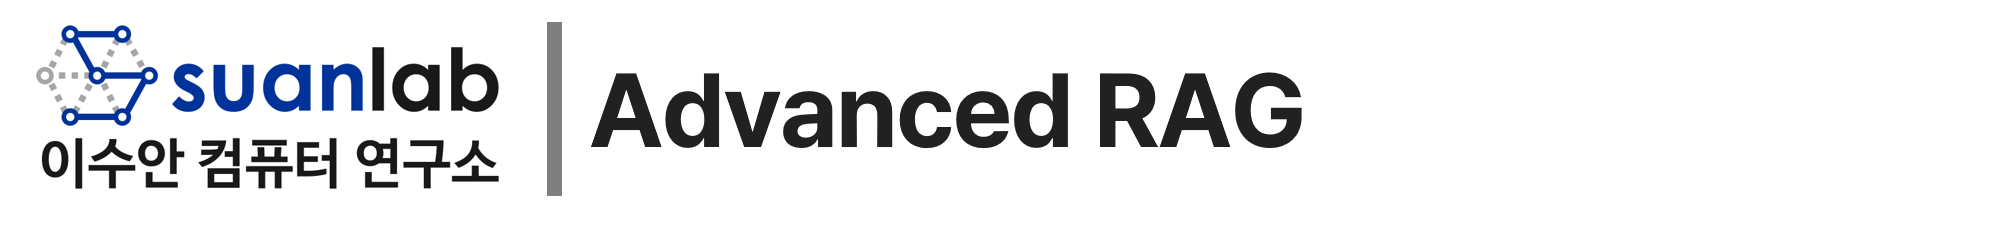

# 🔎 RAG 평가 — 베이스라인부터 평가·편향까지


## 환경 셋업 (맨 처음 한 번만 실행)

In [1]:
# === 환경 셋업 — 이 통합 노트북에서 "한 번만" 실행하면 전체 파트에서 그대로 씁니다 ===
# 비-Claude 라이브러리는 검색·그래프 인프라용입니다(Claude는 임베딩·BM25·리랭크·그래프 미제공)
!pip install -q "anthropic>=0.40" sentence-transformers faiss-cpu matplotlib

import os, getpass, json, re, math, random, collections, textwrap
if not os.environ.get("ANTHROPIC_API_KEY"):
    os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Anthropic API Key: ")
from anthropic import Anthropic
client = Anthropic()
MODEL = "claude-sonnet-4-6"   # 정확도가 중요한 judge·추출 단계는 "claude-opus-4-8"로 상향 가능
print("환경 셋업 완료 — API 키 입력됨, client·MODEL 준비됨")

Anthropic API Key: ··········
환경 셋업 완료 — API 키 입력됨, client·MODEL 준비됨


In [2]:
# 한글 폰트 설정 (Colab 환경)
!apt-get install -y fonts-nanum > /dev/null 2>&1
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print("한글 폰트 설정 완료!")

한글 폰트 설정 완료!


## 현행 모델 라인업 & 최신 API 옵션 (2026 기준)
실습은 **`claude-sonnet-4-6`** 으로 고정(비용·속도·안정성 균형)  
아래는 참고용 라인업이며, judge·트리플 추출처럼 정확도가 결과를 좌우하는 단계에서는 **`claude-opus-4-8`** 로 상향 필요

| 모델 | API ID | 컨텍스트 | 가격(입력/출력, /MTok) | 자리매김 |
|---|---|---:|---|---|
| Fable 5 | `claude-fable-5` | 1M | $10 / $50 | 최상위·최난도 장기 에이전트 |
| Opus 4.8 | `claude-opus-4-8` | 1M | $5 / $25 | 어려운 judge·트리플 추출 상향용 |
| **Sonnet 4.6** | `claude-sonnet-4-6` | 1M | $3 / $15 | **실습 기본 — 본 과정 전 노트북 고정** |
| Haiku 4.5 | `claude-haiku-4-5` | 200K | $1 / $5 | 최저가·대량 호출 |

**선택 가이드**: 대량 생성·요약·Self-Query → Sonnet 4.6/Haiku 4.5 · 어려운 judge·추출 → **Opus 4.8로 상향** · 최고난도 장기 에이전트 → Fable 5

**최신 API 옵션(노트)**
- **prompt caching**: 안 바뀌는 앞부분(rubric·context·문서 전문)을 캐시 → 반복 호출 비용 최대 90%↓ (`cache_control: {"type":"ephemeral"}`)
- **Batches API**: 실시간 불필요한 대량 채점은 묶어서 50% 할인(비동기, 최대 24h)
- **adaptive thinking**: 추론 토큰은 `thinking={"type":"adaptive"}` + `output_config={"effort":...}` 사용  
- 구식 `budget_tokens`는 최신 모델에서 deprecated/오류 → 쓰지 않음
- **structured outputs**: 기존 `tool_use` 강제도 유효하고, 신규 코드는 `output_config={"format":{"type":"json_schema",...}}` 또는 `client.messages.parse(output_format=PydanticModel)`도 가능

> 모델명만 바꾸면 동작: 실제 가용 모델이 다르면 셋업 셀의 `MODEL = ...` 한 줄만 교체


---
# 베이스라인 RAG 서비스 구축

## 학습목표
- 이후 모든 실습의 **출발점**이 되는 최소 RAG QA 서비스를 Claude로 구축
- RAG의 전체 흐름을 한 번에 체득: **문서 → 청킹 → 임베딩 → 벡터검색 → Claude 답변**

## 사전개념
- **청킹(Chunking)**: 긴 문서를 검색 단위로 자름
- **임베딩(Embedding)**: 텍스트를 의미 벡터로 변환
- **벡터검색**: 질문 벡터와 가장 가까운 청크를 찾음
- **RAG 흐름**: 검색된 근거를 LLM에게 주고 근거 기반 답변 생성

> LLM은 Claude API 기본, 임베딩/검색만 비-Claude

## 용어 미니 사전
코드를 잘 몰라도 아래 뜻만 알면 흐름을 따라올 수 있습니다.

| 용어 | 한 줄 뜻 |
|---|---|
| **RAG** | 먼저 관련 문서를 찾아서 그 내용을 근거로 LLM이 답하게 하는 방식 (검색+생성) |
| **청킹(chunking)** | 긴 문서를 검색하기 좋은 작은 조각으로 자르는 것 |
| **임베딩(embedding)** | 문장의 *의미*를 숫자 여러 개(벡터)로 바꾼 것. 의미가 비슷하면 숫자도 비슷 |
| **벡터(vector)** | 숫자들의 묶음. 여기선 문장 의미를 좌표처럼 표현한 것 |
| **코사인 유사도** | 두 벡터가 *얼마나 같은 방향*을 보는지(=의미가 비슷한지) 0~1로 잰 값 |
| **top-k 검색** | 질문과 가장 비슷한 상위 k개 조각을 골라오는 것 |
| **FAISS** | 벡터들 중 가장 비슷한 것을 빠르게 찾아주는 검색 도구 |
| **Hit@k** | 정답이 상위 k개 안에 들어왔으면 1, 아니면 0 (검색이 잘 됐는지 점수) |

> 실습의 한 문장 요약: **문서를 조각내고 → 의미를 숫자로 바꾸고 → 질문과 가까운 조각을 찾아 → Claude가 그 근거로 답한다.**


### Claude에게 말 거는 함수
`ask_claude(...)`는 **질문 문장을 Claude에게 보내고 답을 받아오는** 작은 도구(함수)  
앞으로 모든 실습에서 이 함수로 Claude를 부름

맨 아래 `print(...)`는 "RAG가 뭔지 한 문장으로 설명해줘"라고 시험 삼아 물어보는 것 → **답이 한 줄 출력되면 Claude 연결 성공**


In [3]:
# 기본 Claude 생성 호출 (모든 실습 공통 유틸)
def ask_claude(prompt, system=None, model=MODEL, max_tokens=1024):
    msg = client.messages.create(
        model=model, max_tokens=max_tokens,
        system=system or "당신은 정확하고 근거 기반으로 답하는 도우미입니다.",
        messages=[{"role": "user", "content": prompt}],
    )
    return msg.content[0].text

print(ask_claude("한 문장으로 RAG가 무엇인지 설명해줘."))

**RAG(Retrieval-Augmented Generation)**는 외부 지식 베이스에서 관련 정보를 검색(Retrieve)하여 그 내용을 바탕으로 LLM이 더 정확하고 최신의 답변을 생성(Generate)하는 기술입니다.


## 합성 금융 문서 정의
- 가상 기업 데이터로 외부 의존을 없애기(민감정보·저작권 회피)  
- 모두 **가상 데이터**

### 실습용 가짜 문서 준비
- 검색 대상이 될 **가상의 금융 문서 12건**을 만들기
- 모두 지어낸 기업·수치라 민감정보가 아님
- 실제 업무에선 이 자리에 사내 문서/FAQ가 들어감


In [4]:
# 합성 금융 FAQ/뉴스 (가상 기업 — 실제 기업/사실 아님)
DOCS = [
    "노바테크(NovaTech)는 2023년 매출 1조 2천억 원, 영업이익 1,800억 원을 기록한 가상의 반도체 설계 기업이다.",
    "노바테크의 CEO는 김하늘이며, 2021년 취임 후 AI 가속기 사업으로 사업 영역을 확장했다.",
    "그린모빌리티(GreenMobility)는 전기차 배터리를 생산하는 가상 기업으로, 노바테크로부터 2022년 500억 원의 전략적 투자를 받았다.",
    "그린모빌리티의 2023년 매출은 8천억 원이며, 주력 제품은 고밀도 리튬인산철 배터리다.",
    "오션로지스틱스(OceanLogistics)는 가상의 해운 물류 기업으로, 그린모빌리티의 배터리 원자재를 운송하는 공급 파트너다.",
    "노바테크는 경쟁사인 퀀텀칩(QuantumChip)과 AI 가속기 시장에서 점유율 경쟁 중이다.",
    "퀀텀칩은 2023년 신규 데이터센터용 칩을 출시했고, 매출 9천억 원을 달성했다.",
    "노바테크의 자회사 노바소프트(NovaSoft)는 가상의 클라우드 소프트웨어 기업으로, 연 매출 2천억 원 규모다.",
    "그린모빌리티의 CFO는 박서준이며, 2024년 IPO를 준비 중이라고 가상 공시에서 밝혔다.",
    "오션로지스틱스는 친환경 연료 선박 도입으로 2023년 탄소배출을 전년 대비 12% 감축했다.",
    "노바테크는 배당 정책으로 2023년 주당 800원의 현금배당을 결정했다.",
    "퀀텀칩과 노바테크는 공통 공급사로 정밀소재(PrecisionMat)라는 가상 소재 기업을 두고 있다.",
]
print(f"문서 {len(DOCS)}건 로드 완료")

문서 12건 로드 완료


## 청킹
- 문서가 짧으므로 문장 단위가 곧 청크
- 실제로는 토큰 길이 기반 청킹을 사용

### 문서를 조각(청크)으로 자르기
- 긴 문서를 검색 단위인 **청크**로 자름
- 여기선 문장이 짧아 문장 1개 = 청크 1개로 둠
- 출력으로 청크 개수와 앞 3개를 보여줌
- **문장 단위로 잘렸는지** 눈으로 확인하기


In [5]:
def chunk_docs(docs, chunk_size=1):
    # chunk_size = 청크당 묶을 문장 수 (여기선 문장이 짧아 1로 충분)
    # 나중에 이 값을 바꿔 영향을 관찰하기
    chunks = []
    for d in docs:
        sents = [s.strip() for s in d.split(". ") if s.strip()]
        for i in range(0, len(sents), chunk_size):
            chunks.append(". ".join(sents[i:i+chunk_size]))
    return chunks

CHUNKS = chunk_docs(DOCS, chunk_size=1)
print(f"청크 {len(CHUNKS)}개")
CHUNKS[:3]

청크 12개


['노바테크(NovaTech)는 2023년 매출 1조 2천억 원, 영업이익 1,800억 원을 기록한 가상의 반도체 설계 기업이다.',
 '노바테크의 CEO는 김하늘이며, 2021년 취임 후 AI 가속기 사업으로 사업 영역을 확장했다.',
 '그린모빌리티(GreenMobility)는 전기차 배터리를 생산하는 가상 기업으로, 노바테크로부터 2022년 500억 원의 전략적 투자를 받았다.']

## 임베딩
- `sentence-transformers`의 다국어 경량 모델을 사용(Colab 친화)
- Claude는 임베딩을 제공하지 않으므로 비-Claude

### 문장을 '의미 숫자(임베딩)'로 바꾸기
- 각 청크를 **임베딩**(의미를 담은 숫자 벡터)으로 변환
- 이래야 컴퓨터가 의미가 비슷한지 계산할 수 있음
- `embedder`는 한국어를 아는 경량 변환 모델 (처음 실행 시 모델을 내려받아 잠깐 시간 걸림)
- 출력 `shape: (청크수, 384)`는 "청크 하나가 숫자 384개로 표현됐다"는 뜻


In [6]:
from sentence_transformers import SentenceTransformer
import numpy as np

# 경량 다국어 모델: 한국어 포함, Colab에서 빠름.
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

def embed(texts):
    return np.array(embedder.encode(texts, normalize_embeddings=True), dtype="float32")

DOC_EMB = embed(CHUNKS)
print("임베딩 shape:", DOC_EMB.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

임베딩 shape: (12, 384)


## FAISS 인덱스
- 정규화 벡터에 내적(IP) 인덱스 = 코사인 유사도 검색

### 빠른 검색을 위한 '색인' 만들기
- 임베딩들을 **FAISS 색인**에 넣음
- 색인은 도서관 색인표처럼, 질문과 가장 비슷한 청크를 빠르게 찾게함
- 정규화된 벡터에서 내적(IP)은 곧 **코사인 유사도**(의미 방향 비슷함)와 같음


In [7]:
import faiss
dim = DOC_EMB.shape[1]
index = faiss.IndexFlatIP(dim)   # 정규화 임베딩이므로 내적 = 코사인 유사도
index.add(DOC_EMB)
print("인덱스에 등록된 벡터 수:", index.ntotal)

인덱스에 등록된 벡터 수: 12


## top-k 검색

### 질문과 가까운 청크 top-k 찾기
- 질문을 같은 방식으로 임베딩한 뒤, 색인에서 **가장 비슷한 청크 k개**를 점수와 함께 가져옴
- **출력 읽는 법**: 각 줄 앞 숫자(예: `0.612`)가 유사도 점수
- **클수록 질문과 의미가 가깝다**는 뜻이고, 보통 CEO 질문이면 김하늘이 나오는 문장이 맨 위에 옴


In [8]:
def search(query, k=4):
    q = embed([query])
    scores, idx = index.search(q, k)
    return [(CHUNKS[i], float(s)) for i, s in zip(idx[0], scores[0])]

for c, s in search("노바테크의 CEO는 누구인가?"):
    print(f"{s:.3f}  {c}")

0.597  노바테크의 CEO는 김하늘이며, 2021년 취임 후 AI 가속기 사업으로 사업 영역을 확장했다.
0.350  그린모빌리티의 CFO는 박서준이며, 2024년 IPO를 준비 중이라고 가상 공시에서 밝혔다.
0.309  노바테크의 자회사 노바소프트(NovaSoft)는 가상의 클라우드 소프트웨어 기업으로, 연 매출 2천억 원 규모다.
0.277  노바테크(NovaTech)는 2023년 매출 1조 2천억 원, 영업이익 1,800억 원을 기록한 가상의 반도체 설계 기업이다.


## `rag_answer()` — Claude 근거 기반 답변
- 검색된 근거만 사용하도록 system 프롬프트로 제약하고 근거 번호 인용을 강제

### 찾은 근거로 Claude가 답하게 만들기
- 검색된 청크들을 **근거로 묶어** Claude에게 주고, 근거에 있는 내용만 답하도록 규칙(system 프롬프트)을 걸기
- 답 끝에 `[1] [2]`처럼 **사용한 근거 번호**를 달게 해 환각(없는 말 지어내기)을 줄임


In [9]:
def rag_answer(question, contexts):
    ctx = "\n\n".join(f"[{i+1}] {c}" for i, c in enumerate(contexts))
    system = ("주어진 근거 문서만 사용해 답하라. 근거에 없으면 '근거 없음'이라고 말하라. "
              "답변 끝에 사용한 근거 번호를 [n]으로 표기하라.")
    return ask_claude(f"근거:\n{ctx}\n\n질문: {question}", system=system)

## `ask()` 래퍼
- 검색 + 생성을 한 함수로 묶음
- 이것이 베이스라인 RAG 서비스의 진입점

### 검색+답변을 한 번에 (`ask`)
- `ask(질문)` 하나로 **검색 → 근거 묶기 → Claude 답변**까지 자동으로 함
- 이것이 미니 RAG 서비스의 입구
- **출력 읽는 법**: 답변 문장 끝에 `[숫자]` 인용이 붙어 있으면 근거를 보고 답했다는 신호


In [10]:
def ask(question, k=4):
    hits = search(question, k=k)
    contexts = [c for c, _ in hits]
    return rag_answer(question, contexts)

print(ask("노바테크의 CEO는 누구인가?"))

노바테크의 CEO는 **김하늘**입니다. 2021년 취임 후 AI 가속기 사업으로 사업 영역을 확장했습니다. [1]


## 직접 해보기: 청크 크기 변경
- 청크 크기를 바꿔 검색/답변 품질에 미치는 영향을 관찰하기

In [11]:
# 🔧 직접 해보기: 청크 크기를 바꾸면 검색/답변이 어떻게 달라질까요?
# 힌트: 아래 3줄을 순서대로 실행하면 청크를 2문장씩 묶어 다시 검색까지 됩니다.
#   (1) 청크 다시 만들기
#   (2) 임베딩 다시 만들기
#   (3) 색인 다시 만들고 같은 질문 던지기
my_chunk_size = 2  # <- 1, 2, 3 으로 바꿔보세요 (숫자가 클수록 한 조각에 더 많은 문장)

# (1) 새 청크
CHUNKS2 = chunk_docs(DOCS, chunk_size=my_chunk_size)
# (2) 새 임베딩
EMB2 = embed(CHUNKS2)
# (3) 새 색인 + 검색
import faiss as _f
idx2 = _f.IndexFlatIP(EMB2.shape[1]); idx2.add(EMB2)
_q = embed(['노바테크의 CEO는 누구인가?'])
_, _ids = idx2.search(_q, 3)
print(f'청크 {len(CHUNKS2)}개로 다시 검색한 top-3:')
for _i in _ids[0]:
    print('  ', CHUNKS2[_i])
# 관찰 포인트: 청크가 커지면 한 조각에 맥락이 많아지지만, 엉뚱한 문장이 딸려올 수도 있어요.


청크 12개로 다시 검색한 top-3:
   노바테크의 CEO는 김하늘이며, 2021년 취임 후 AI 가속기 사업으로 사업 영역을 확장했다.
   그린모빌리티의 CFO는 박서준이며, 2024년 IPO를 준비 중이라고 가상 공시에서 밝혔다.
   노바테크의 자회사 노바소프트(NovaSoft)는 가상의 클라우드 소프트웨어 기업으로, 연 매출 2천억 원 규모다.


## 검증
질문 3개에 근거 인용([n])이 포함된 답변이 나오고, 전체 셀이 에러 없이 실행되는지 확인

### 잘 만들어졌는지 자동 점검(검증)
- `assert`는 "이게 참이어야 한다"는 **자동 검사**
- 색인 크기가 맞는지, 답변에 근거 인용이 있는지 확인 맨 끝에 `... 통과`가 보이면 정상 (검사가 틀리면 에러로 멈춰 알려줌)


In [12]:
assert index.ntotal == len(CHUNKS), "인덱스 크기가 청크 수와 다릅니다"
questions = [
    "노바테크의 CEO는 누구인가?",
    "그린모빌리티는 어떤 제품을 만드는가?",
    "노바테크의 경쟁사는?",
]
for q in questions:
    ans = ask(q)
    print("Q:", q)
    print("A:", ans, "\n")
    assert "[" in ans and "]" in ans, "근거 번호 인용이 없습니다"
print("베이스라인 RAG 서비스 검증 통과")

Q: 노바테크의 CEO는 누구인가?
A: 노바테크의 CEO는 **김하늘**입니다. 2021년에 취임하였으며, 취임 후 AI 가속기 사업으로 사업 영역을 확장하였습니다. [1] 

Q: 그린모빌리티는 어떤 제품을 만드는가?
A: 그린모빌리티는 **전기차 배터리**를 생산하며, 주력 제품은 **고밀도 리튬인산철 배터리**입니다. [1][2] 

Q: 노바테크의 경쟁사는?
A: 노바테크의 경쟁사는 **퀀텀칩(QuantumChip)**입니다. 노바테크와 퀀텀칩은 AI 가속기 시장에서 점유율 경쟁을 벌이고 있습니다. [1] 

베이스라인 RAG 서비스 검증 통과


## 개념 복습 · 청킹 전략
- **청킹은 RAG 품질의 첫 레버리지**

| 전략 | 방식 | 장점 | 단점 |
|---|---|---|---|
| **고정 길이(fixed)** | N글자/토큰마다 자른다 | 단순·균일 | 문장 중간에서 끊겨 의미 손상 |
| **문장 단위(sentence)** | 문장 경계로 자른다 | 의미 보존 | 청크 길이 들쭉날쭉, 짧으면 맥락 부족 |
| **오버랩(overlap)** | 인접 청크가 일부 겹친다 | 경계 정보 손실 완화 | 중복·인덱스 비대 |

아래에서 세 전략을 같은 코퍼스에 적용하고 **검색 Hit@k로 정량 비교**

## 세 가지 청킹 전략 구현
- 문서를 더 길게 만들어(여러 문장 결합) 청킹 차이가 드러나게 함

### 더 긴 문서로 바꾸기
- 청킹 전략 차이를 눈으로 보려면 문서가 길어야 함

In [13]:
# 긴 문서 코퍼스: 한 문서에 여러 사실을 묶어 청킹 전략 차이를 부각
LONG_DOCS = [
    "노바테크(NovaTech)는 2023년 한 해 동안 놀라운 재무 성과를 달성했다. 연간 매출액은 1조 2천억 원에 달했으며, 이는 전년 대비 20% 성장한 수치이다. 또한, 견고한 영업이익 1,800억 원을 기록하여 시장의 기대를 뛰어넘었다. 노바테크의 현재 CEO는 2021년에 취임한 김하늘 대표이사이다. 김하늘 CEO는 취임 이후 회사의 핵심 성장 동력으로 AI 가속기 사업 분야를 적극적으로 확장해왔으며, 이는 최근 매출 증대에 크게 기여했다. 이러한 성공적인 경영 성과를 바탕으로, 노바테크는 주주 환원 정책의 일환으로 2023년 회계연도에 주당 800원의 현금배당을 실시하기로 결정했다. 이 결정은 주주들에게 긍정적인 신호로 해석되고 있다.",
    "그린모빌리티(GreenMobility)는 혁신적인 전기차 배터리 기술을 선도하는 가상의 기업으로, 친환경 이동수단 시장의 핵심 플레이어로 자리매김하고 있다. 이 기업은 2022년에 노바테크로부터 500억 원 규모의 전략적 투자를 유치하며 기술 개발 및 생산 능력 확장에 박차를 가했다. 2023년에는 8천억 원이라는 인상적인 매출을 기록했으며, 이는 전 세계적인 전기차 수요 증가와 고품질 배터리에 대한 시장의 높은 평가 덕분이다. 그린모빌리티의 주력 제품은 뛰어난 안정성과 효율성을 자랑하는 고밀도 리튬인산철 배터리이다. 현재 CFO인 박서준 이사는 2024년을 목표로 기업공개(IPO)를 적극적으로 준비하고 있다고 공식 발표하여, 투자자들의 큰 관심을 받고 있다. IPO를 통해 조달된 자금은 추가적인 연구 개발과 글로벌 시장 확장에 사용될 예정이다.",
    "오션로지스틱스(OceanLogistics)는 글로벌 해운 및 물류 서비스를 제공하는 선도적인 가상 기업이다. 특히, 친환경 전기차 배터리 제조업체인 그린모빌리티의 핵심 원자재 운송을 전담하며 긴밀한 파트너십을 유지하고 있다. 이 회사는 지속 가능한 경영을 목표로 적극적인 환경 보호 노력을 기울이고 있으며, 그 일환으로 2023년에는 최신 친환경 연료 선박을 대규모로 도입했다. 이러한 노력의 결과로 2023년 한 해 동안 탄소배출량을 전년 대비 12%나 성공적으로 감축하는 성과를 거두었다. 이는 해운 물류 산업에서 환경적 책임을 다하는 모범 사례로 평가받고 있다.",
    "퀀텀칩(QuantumChip)은 고성능 반도체 솔루션을 제공하는 혁신적인 기업으로, 2023년에는 특히 데이터센터용 신형 칩을 성공적으로 출시하며 시장의 주목을 받았다. 이 신제품의 성공적인 판매에 힘입어 퀀텀칩은 9천억 원의 매출을 달성하는 쾌거를 이루었다. 퀀텀칩은 인공지능(AI) 가속기 시장에서 노바테크(NovaTech)와 치열한 점유율 경쟁을 벌이고 있는 주요 경쟁사 중 하나이다. 양사 모두 이 분야에서 기술 리더십을 확보하기 위해 끊임없이 노력하고 있다. 흥미롭게도, 노바테크와 퀀텀칩이라는 두 경쟁사는 정밀소재(PrecisionMat)라는 가상의 기업으로부터 핵심 부품 및 원자재를 공급받는 공통 공급망을 가지고 있다. 이는 반도체 산업의 복잡한 생태계를 보여주는 단면이다."
]
print(f"긴 문서 {len(LONG_DOCS)}건, 평균 길이 {sum(len(d) for d in LONG_DOCS)//len(LONG_DOCS)}자")

긴 문서 4건, 평균 길이 372자


### 세 가지 자르기 방식 만들기
- **고정 길이(fixed)**: 글자 수로 뚝뚝 자르기 (문장 중간에서 끊길 수 있음)
- **문장 단위(sentence)**: 문장 경계로 자르기 (의미 보존)
- **오버랩(overlap)**: 조각끼리 일부 겹치게 자르기 (경계 정보 손실 완화)
- 출력은 방식별 청크 수와 평균 길이


In [14]:
def chunk_fixed(docs, size=60, overlap=0):
    """고정 길이(문자) 청킹. overlap>0이면 오버랩 전략."""
    chunks = []
    for d in docs:
        step = max(1, size - overlap)
        for i in range(0, len(d), step):
            piece = d[i:i+size].strip()
            if piece:
                chunks.append(piece)
    return chunks

def chunk_sentence(docs):
    """문장 경계 청킹."""
    chunks = []
    for d in docs:
        for s in d.split(". "):
            s = s.strip().rstrip(".")
            if s:
                chunks.append(s)
    return chunks

strategies = {
    "fixed(60,0)":   chunk_fixed(LONG_DOCS, size=60, overlap=0),
    "sentence":      chunk_sentence(LONG_DOCS),
    "overlap(60,20)":chunk_fixed(LONG_DOCS, size=60, overlap=20),
}
for name, ch in strategies.items():
    print(f"{name:14s} 청크 {len(ch):2d}개, 평균 {sum(len(c) for c in ch)//len(ch)}자")

fixed(60,0)    청크 28개, 평균 52자
sentence       청크 24개, 평균 60자
overlap(60,20) 청크 39개, 평균 55자


## 전략별 인덱스 구축 + 검색 평가
- 각 전략으로 별도 FAISS 인덱스를 만들고, 같은 질문셋으로 **정답 키워드가 top-k 청크에 포함되는지**(Hit@k)를 측정 (임베딩=비-Claude. 정답 판정은 키워드 포함으로 단순화 — lab1에서 정식 지표로 발전)

### 전략별로 검색 성능 점수 매기기
- 세 자르기 방식 각각으로 색인을 만들고, 질문 6개에 대해 정답 단어가 상위 4개 조각 안에 있는지(Hit@4)를 세기
- **Hit@4가 높을수록 그 자르기 방식이 검색에 유리**함


In [15]:
def build_index(chunks):
    emb = embed(chunks)
    idx = faiss.IndexFlatIP(emb.shape[1]); idx.add(emb)
    return idx

def search_chunks(idx, chunks, query, k=4):
    q = embed([query]); _, ids = idx.search(q, min(k, len(chunks)))
    return [chunks[i] for i in ids[0]]

# 질문 + 정답 키워드(이 키워드가 검색된 청크 안에 있으면 Hit)
QSET = [
    ("노바테크의 CEO는 누구인가?", "김하늘"),
    ("그린모빌리티의 주력 제품은?", "리튬인산철"),
    ("노바테크의 2023년 배당은?", "800"),
    ("탄소배출을 줄인 물류 기업은?", "오션로지스틱스"),
    ("노바테크와 퀀텀칩의 공통 공급사는?", "정밀소재"),
    ("그린모빌리티의 CFO는?", "박서준"),
]

def hit_rate(idx, chunks, k=4):
    hits = 0
    for q, kw in QSET:
        got = search_chunks(idx, chunks, q, k)
        if any(kw in c for c in got):
            hits += 1
    return hits / len(QSET)

results = {}
for name, ch in strategies.items():
    idx = build_index(ch)
    hr = hit_rate(idx, ch, k=4)
    results[name] = {"chunks": len(ch), "hit@4": hr}
    print(f"{name:14s} 청크 {len(ch):2d}개  Hit@4={hr:.3f}")

fixed(60,0)    청크 28개  Hit@4=0.500
sentence       청크 24개  Hit@4=0.833
overlap(60,20) 청크 39개  Hit@4=0.833


## 비교 시각화 & 분석
- 막대그래프로 전략별 Hit@4를 눈으로 비교하고, **왜 이런 결과인가**를 해설

### 결과를 막대그래프로 보기
- 숫자만 보면 와닿지 않으니 **막대그래프**로 그리기
- 왼쪽은 전략별 Hit@4(높을수록 좋음), 오른쪽은 청크 수(많을수록 저장·검색 비용↑)
- **그래프 읽는 법**: 막대가 높은 전략이 검색을 더 잘한 것
- 단, 청크 수(오른쪽)가 많으면 그만큼 비용이 든다는 트레이드오프를 함께 보기


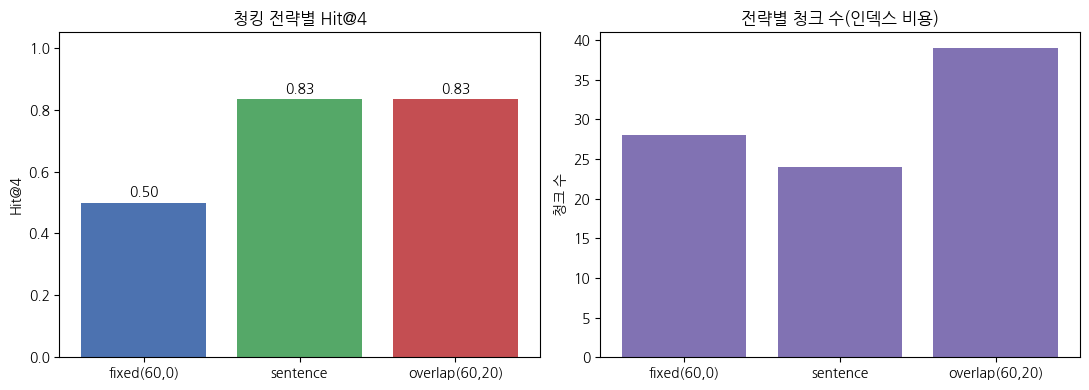

In [16]:
import matplotlib.pyplot as plt

names = list(results.keys())
hits = [results[n]["hit@4"] for n in names]
nchunks = [results[n]["chunks"] for n in names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
bars = ax1.bar(names, hits, color=["#4C72B0", "#55A868", "#C44E52"])
ax1.set_title("청킹 전략별 Hit@4"); ax1.set_ylabel("Hit@4"); ax1.set_ylim(0, 1.05)
for b, h in zip(bars, hits):
    ax1.text(b.get_x()+b.get_width()/2, h+0.02, f"{h:.2f}", ha="center")
ax2.bar(names, nchunks, color="#8172B3")
ax2.set_title("전략별 청크 수(인덱스 비용)"); ax2.set_ylabel("청크 수")
plt.tight_layout(); plt.show()

### 결과 해석 (예시 가이드)
- **문장 단위**는 보통 의미 경계가 보존돼 키워드 청크를 잘 찾음
- **고정 길이**(overlap 0)는 사실이 청크 경계에서 잘려 일부 질문에서 Hit가 떨어질 수 있음
- **오버랩**은 경계 손실을 완화해 고정 길이보다 Hit가 오르는 대신 **청크 수(=인덱스 비용)가 늘어남**
- 정답은 도메인·문서 길이마다 다름 → **측정해서 고름**(lab1의 정식 지표로 확장)

## 직접 해보기: 오버랩 크기 스윕
- 오버랩을 0/10/20/30으로 바꿔 Hit@4와 청크 수가 어떻게 변하는지 직접 표로 만들어 보기

In [17]:
# 🔧 직접 해보기: 오버랩(겹침)을 키우면 Hit@4와 청크 수가 어떻게 변할까요?
# 힌트: 주석을 풀고 빈칸을 채우세요. build_index와 hit_rate는 위에서 이미 만들었습니다.
for ov in [0, 10, 20, 30]:
    ch = chunk_fixed(LONG_DOCS, size=60, overlap=ov)
    idx = build_index(ch)          # <- 색인 만들기
    hr = hit_rate(idx, ch, k=4)    # <- 점수 재기
    print(f'overlap={ov:2d}  청크={len(ch):2d}  Hit@4={hr:.3f}')
# 관찰: 겹침이 커지면 보통 Hit@4가 오르지만 청크 수(=비용)도 함께 늘어납니다.


overlap= 0  청크=28  Hit@4=0.500
overlap=10  청크=32  Hit@4=0.500
overlap=20  청크=39  Hit@4=0.833
overlap=30  청크=52  Hit@4=0.833


## 검증: 청킹 전략

In [18]:
# 오버랩이 있으면 인접 청크가 일부 문자를 공유해야 함
ov_chunks = chunk_fixed(["가나다라마바사아자차카타파하" * 3], size=12, overlap=4)
assert len(ov_chunks) >= 2, "오버랩 청킹이 여러 청크를 만들어야 함"
# 모든 전략의 Hit@4가 0~1 범위
for n, r in results.items():
    assert 0.0 <= r["hit@4"] <= 1.0, f"{n} Hit 범위 오류"
print("청킹 전략 비교 검증 통과")

청킹 전략 비교 검증 통과


## 확장과제
- **청크 크기/오버랩 스윕**: 위 비교를 size=40/80/120으로도 돌려 최적점을 찾기
- **토큰 기반 청킹**: 문자 수 대신 토큰 수로 자르면(`tiktoken`/`transformers` 토크나이저) 어떻게 달라지나?
- 문서를 추가하고 새로운 질문에 답하게 해보기
- top-k를 늘리면 답변이 어떻게 달라지는가? (다음 lab1에서 정량 평가)

> 이 노트북의 `DOCS`, `embed`, `search`, `rag_answer`, `ask`는 lab1과 lab5에서 재사용
> 청킹 전략 비교(`chunk_fixed`/`chunk_sentence`)는 실무에서 RAG 품질의 첫 튜닝 포인트

---
# RAG 평가 (검색지표 + Claude LLM-as-a-judge)

## 학습목표
- 검색 성능을 **Hit@k / MRR / nDCG**로 직접 구현해 측정
- 생성 품질을 **Claude judge**로 faithfulness / answer_relevancy 채점
- 점수표로 약점(검색 vs 생성)을 진단

## 사전개념
- **RAG** 위에서 평가
- **검색지표**: Hit@k(정답이 top-k에 있나), MRR(첫 정답의 역순위 평균), nDCG(순위 가중 이득)
- **Faithfulness**: 답변이 근거에 충실한가. **Answer Relevancy**: 답변이 질문에 맞는가
- **LLM-as-a-judge**: LLM으로 답변을 채점. tool use로 구조화 출력을 강제해 파싱 안정화

> "측정할 수 없으면 개선할 수 없다." 검색과 생성을 **분리**해 측정한다.

## 용어 미니 사전 (평가 편)
이 실습은 "우리 RAG가 얼마나 잘하는지 점수로 재는" 방법을 배우기

| 용어 | 한 줄 뜻 |
|---|---|
| **골든 QA셋** | 사람이 정답을 미리 정해둔 시험 문제지(질문+정답 근거) |
| **Hit@k** | 정답 근거가 상위 k개 검색결과 안에 들어왔으면 1, 아니면 0 |
| **MRR** | 정답이 *몇 번째*로 나왔는지의 역수 평균(위에 빨리 나올수록 점수↑) |
| **nDCG** | 정답이 위쪽 순위일수록 더 높게 쳐주는 검색 품질 점수 |
| **Faithfulness(충실도)** | 답이 *근거에 적힌 내용*에만 충실한가(지어내지 않았나) |
| **Answer Relevancy(적합도)** | 답이 *질문에 맞는* 내용인가 |
| **LLM-as-a-judge** | 사람 대신 LLM(여기선 Claude)이 답을 채점하게 하는 것 |
| **rubric(루브릭)** | 채점 기준 문장. 기준이 바뀌면 점수도 바뀜 |

> 핵심 메시지: **검색이 잘됐는지**와 **답을 잘 썼는지**를 따로 측정. 검색이 0점이면 답은 의미가 없음


## RAG 재구성

### - 미니 RAG를 다시 구축
- **검색+답변 기능을 압축해서 다시 만들기**  (문서→임베딩→색인→검색→답변)


In [19]:
import numpy as np, faiss
from sentence_transformers import SentenceTransformer

DOCS = [
    "노바테크(NovaTech)는 2023년 매출 1조 2천억 원을 기록한 가상의 반도체 설계 기업이다.",
    "노바테크의 CEO는 김하늘이며 2021년 취임했다.",
    "그린모빌리티(GreenMobility)는 전기차 배터리 생산 가상 기업으로 노바테크로부터 2022년 500억 원 투자를 받았다.",
    "그린모빌리티의 2023년 매출은 8천억 원이며 주력 제품은 리튬인산철 배터리다.",
    "오션로지스틱스(OceanLogistics)는 그린모빌리티의 배터리 원자재를 운송하는 가상 해운 물류 기업이다.",
    "노바테크는 경쟁사 퀀텀칩(QuantumChip)과 AI 가속기 시장에서 경쟁한다.",
    "퀀텀칩은 2023년 데이터센터용 칩을 출시하고 매출 9천억 원을 달성했다.",
    "노바테크의 자회사 노바소프트(NovaSoft)는 가상 클라우드 소프트웨어 기업이다.",
    "그린모빌리티의 CFO 박서준은 2024년 IPO를 준비 중이라고 밝혔다.",
    "노바테크는 2023년 주당 800원의 현금배당을 결정했다.",
]
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")  # 임베딩=비-Claude
def embed(texts):
    return np.array(embedder.encode(texts, normalize_embeddings=True), dtype="float32")
DOC_EMB = embed(DOCS)
index = faiss.IndexFlatIP(DOC_EMB.shape[1]); index.add(DOC_EMB)

def search_ids(query, k=4):
    q = embed([query]); _, idx = index.search(q, k)
    return list(idx[0])
def search(query, k=4):
    return [DOCS[i] for i in search_ids(query, k)]
def rag_answer(question, contexts):
    ctx = "\n\n".join(f"[{i+1}] {c}" for i, c in enumerate(contexts))
    system = ("주어진 근거만 사용해 답하라. 없으면 '근거 없음'. 끝에 근거 번호 [n] 표기.")
    return ask_claude(f"근거:\n{ctx}\n\n질문: {question}", system=system)
def ask(question, k=4):
    return rag_answer(question, search(question, k))
print("RAG 재구성 완료, 문서", len(DOCS), "건")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RAG 재구성 완료, 문서 10 건


## 골든 QA셋
- Claude로 초안 합성 후 **수기 보정**
- 여기서는 보정된 결과를 직접 정의(재현성)
- `gold_doc`는 정답 근거 문서의 인덱스

### 채점용 정답지(골든 QA셋) 만들기
- 질문마다 **정답 근거 문서 번호**(gold)와 **정답 키워드**를 정해 둠
- 이게 있어야 "맞았다/틀렸다"를 점수로 잴 수 있음
- 실무에선 사람이 직접 만들고 검수하는 부분


In [20]:
# 골든 QA셋: question, 정답근거 문서 인덱스(gold), 정답 키워드
GOLD = [
    {"q": "노바테크의 CEO는 누구인가?", "gold": 1, "answer_kw": "김하늘"},
    {"q": "그린모빌리티의 주력 제품은?", "gold": 3, "answer_kw": "리튬인산철"},
    {"q": "노바테크의 경쟁사는?", "gold": 5, "answer_kw": "퀀텀칩"},
    {"q": "노바테크의 자회사는?", "gold": 7, "answer_kw": "노바소프트"},
    {"q": "그린모빌리티의 CFO는?", "gold": 8, "answer_kw": "박서준"},
    {"q": "노바테크의 2023년 배당은 주당 얼마인가?", "gold": 9, "answer_kw": "800"},
]
print(f"골든 QA {len(GOLD)}건")

골든 QA 6건


## 검색지표 직접 구현 (Hit@k / MRR / nDCG)
- 각 함수는 검색된 문서 id 리스트와 정답 id를 받음

### 검색 점수 계산기 직접 만들기
- 세 가지 검색 점수를 손으로 구현하기
- `hit_at_k`: 정답이 top-k 안에 있나(0/1)
- `mrr`: 정답이 몇 번째로 나왔나(위일수록↑)
- `ndcg_at_k`: 정답이 위쪽일수록 가점
- 아래 `assert ...`는 이 계산기들이 제대로 동작하는지 스스로 검사, `통과`면 정상


In [21]:
import math

def hit_at_k(ranked_ids, gold_id, k):
    return 1.0 if gold_id in ranked_ids[:k] else 0.0

def mrr(ranked_ids, gold_id):
    for rank, did in enumerate(ranked_ids, start=1):
        if did == gold_id:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(ranked_ids, gold_id, k):
    # 단일 정답 가정: 정답 위치의 DCG / 이상적 DCG(1위에 있을 때)
    dcg = 0.0
    for rank, did in enumerate(ranked_ids[:k], start=1):
        rel = 1.0 if did == gold_id else 0.0
        dcg += rel / math.log2(rank + 1)
    idcg = 1.0 / math.log2(1 + 1)  # 정답이 1위일 때
    return dcg / idcg if idcg > 0 else 0.0

# 단위 테스트
assert hit_at_k([2, 5, 1], gold_id=5, k=3) == 1.0
assert hit_at_k([2, 5, 1], gold_id=9, k=3) == 0.0
assert abs(mrr([2, 5, 1], 5) - 0.5) < 1e-9
assert abs(ndcg_at_k([5, 2, 1], 5, 3) - 1.0) < 1e-9  # 1위면 1.0
assert ndcg_at_k([2, 1, 5], 5, 3) < 1.0              # 3위면 1.0 미만
print("검색지표 단위테스트 통과")

검색지표 단위테스트 통과


## 검색지표 집계

### 검색 점수를 전체 평균으로 집계
- 골든 QA 전체에 대해 위 세 점수를 평균 냄
- **출력의 세 숫자(0~1)가 우리 검색기의 성적표**
- 1에 가까울수록 좋음


In [22]:
def eval_retrieval(gold_set, k=4):
    hits, mrrs, ndcgs = [], [], []
    for g in gold_set:
        ranked = search_ids(g["q"], k=k)
        hits.append(hit_at_k(ranked, g["gold"], k))
        mrrs.append(mrr(ranked, g["gold"]))
        ndcgs.append(ndcg_at_k(ranked, g["gold"], k))
    return {"Hit@k": sum(hits)/len(hits), "MRR": sum(mrrs)/len(mrrs), "nDCG": sum(ndcgs)/len(ndcgs)}

retr = eval_retrieval(GOLD, k=4)
print("검색 지표:", {m: round(v, 3) for m, v in retr.items()})

검색 지표: {'Hit@k': 1.0, 'MRR': 0.833, 'nDCG': 0.877}


## LLM-as-a-judge (생성 평가)
- `tool_choice`로 구조화 출력을 **강제**해 파싱을 안정화
- reasoning을 먼저 받아 CoT를 유도(신뢰성 향상)

### Claude를 '채점관(judge)'으로 쓰기
- Claude에게 답변을 **충실도/적합도 1~5점**으로 매기게 함
- `tool`(도구) 형식을 강제해 반드시 정해진 칸에 점수를 내도록 해서 결과를 안정적으로 받아옴
- `reasoning`(채점 이유)을 먼저 쓰게 해 더 신중히 채점하게 함
- **출력 읽는 법**: `{'faithfulness': 5, 'answer_relevancy': 5, ...}` 처럼 점수가 나오면 채점관이 정상 작동한 것


In [23]:
# 정확도가 더 필요하면 이 judge/추출 셀의 모델을 MODEL_JUDGE = "claude-opus-4-8" 로 한 줄 상향 가능(기본은 비용 위해 sonnet 4.6).
JUDGE_TOOL = [{
  "name": "report_judgment",
  "description": "RAG 답변을 평가한 결과를 보고",
  "input_schema": {"type": "object", "properties": {
      "reasoning": {"type": "string", "description": "채점 근거(먼저 생각)"},
      "faithfulness": {"type": "integer", "description": "1-5, 근거 충실도"},
      "answer_relevancy": {"type": "integer", "description": "1-5, 질문 적합도"},
  }, "required": ["reasoning", "faithfulness", "answer_relevancy"]}
}]

def judge(question, answer, contexts):
    ctx = "\n".join(contexts)
    msg = client.messages.create(
        model=MODEL, max_tokens=700,
        tools=JUDGE_TOOL, tool_choice={"type": "tool", "name": "report_judgment"},
        messages=[{"role": "user", "content":
            f"질문:{question}\n근거:{ctx}\n답변:{answer}\n"
            "rubric에 따라 1-5로 채점하라. reasoning을 먼저 생각한 뒤 점수를 매겨라."}],
    )
    for b in msg.content:
        if b.type == "tool_use":
            return b.input

# 데모 1건
demo = GOLD[0]
ctxs = search(demo["q"], k=4)
ans = rag_answer(demo["q"], ctxs)
print("답변:", ans)
print("판정:", judge(demo["q"], ans, ctxs))

답변: 노바테크의 CEO는 **김하늘**이며, 2021년에 취임했습니다. [1]
판정: {'reasoning': '\n**질문 적합도(Answer Relevancy) 평가:**\n질문은 "노바테크의 CEO는 누구인가?"이고, 답변은 "노바테크의 CEO는 **김하늘**이며, 2021년에 취임했습니다."라고 직접적으로 답하고 있다. 질문에 완벽하게 부합하는 답변이며, 불필요한 정보 없이 핵심만 전달하고 있다. → 5점\n\n**근거 충실도(Faithfulness) 평가:**\n근거 문서 중 "노바테크의 CEO는 김하늘이며 2021년 취임했다."라는 문장이 명확히 존재하며, 답변은 이 근거를 그대로 반영하고 있다. 답변 내용이 근거에서 벗어나거나 hallucination을 포함하지 않는다. 출처 표기([1])도 적절하다. → 5점\n', 'faithfulness': 5, 'answer_relevancy': 5}


## 생성지표 집계 + 점수표
- 예상 호출: 골든 QA 6건 × (답변 1 + judge 1) ≈ 12 호출, 소규모라 비용 미미

### 답변 품질을 전 문항 채점
- 골든 QA 전체에 대해 답을 만들고 → Claude가 채점함 (예상 호출: 약 12번, 소규모라 비용은 미미)
- **출력 읽는 법**: 평균 충실도/적합도와 문항별 점수가 나옴
- 특정 질문 점수가 낮으면 그 부분이 우리 시스템의 약점


In [24]:
def eval_generation(gold_set, k=4):
    rows = []
    for g in gold_set:
        ctxs = search(g["q"], k=k)
        ans = rag_answer(g["q"], ctxs)
        j = judge(g["q"], ans, ctxs)
        rows.append({"q": g["q"], "faithfulness": j["faithfulness"],
                     "answer_relevancy": j["answer_relevancy"],
                     "kw_hit": g["answer_kw"] in ans})
    return rows

gen_rows = eval_generation(GOLD, k=4)
import statistics as st
print(f"평균 faithfulness: {st.mean(r['faithfulness'] for r in gen_rows):.2f}")
print(f"평균 answer_relevancy: {st.mean(r['answer_relevancy'] for r in gen_rows):.2f}")
print(f"키워드 정답 비율: {sum(r['kw_hit'] for r in gen_rows)}/{len(gen_rows)}")
for r in gen_rows:
    print(f"  faith={r['faithfulness']} rel={r['answer_relevancy']} kw={r['kw_hit']}  {r['q']}")

평균 faithfulness: 5.00
평균 answer_relevancy: 5.00
키워드 정답 비율: 6/6
  faith=5 rel=5 kw=True  노바테크의 CEO는 누구인가?
  faith=5 rel=5 kw=True  그린모빌리티의 주력 제품은?
  faith=5 rel=5 kw=True  노바테크의 경쟁사는?
  faith=5 rel=5 kw=True  노바테크의 자회사는?
  faith=5 rel=5 kw=True  그린모빌리티의 CFO는?
  faith=5 rel=5 kw=True  노바테크의 2023년 배당은 주당 얼마인가?


## 약점 진단
- 검색 점수와 생성 점수를 함께 보고 병목을 판단

### 약점이 검색인지 생성인지 진단
- 검색 점수와 생성 점수를 함께 보고 **병목**을 가림
- 검색이 낮으면 → 이후 Hybrid/Rerank 실습에서, 생성이 낮으면 → 프롬프트를 손봐야 한다는 안내가 출력


In [25]:
print("=== 진단 ===")
print("검색:", {m: round(v, 3) for m, v in retr.items()})
faith = st.mean(r["faithfulness"] for r in gen_rows)
rel = st.mean(r["answer_relevancy"] for r in gen_rows)
if retr["Hit@k"] < 0.8:
    print("→ 검색 병목: 정답 문서가 top-k에 자주 누락. 모듈2(Hybrid/Rerank)에서 개선")
elif faith < 4:
    print("→ 생성 병목: 검색은 되나 답변이 근거에 불충실. 프롬프트/모델 점검")
else:
    print("→ 베이스라인 양호. k·rubric 변경으로 추가 개선 여지 탐색")

=== 진단 ===
검색: {'Hit@k': 1.0, 'MRR': 0.833, 'nDCG': 0.877}
→ 베이스라인 양호. k·rubric 변경으로 추가 개선 여지 탐색


## 직접 해보기: 점수 변화 관찰
- judge rubric을 바꾸거나 검색 k를 바꿔 점수 변화를 관찰하기

In [26]:
# TODO 1: 검색 k를 2로 줄여 eval_retrieval(GOLD, k=2)를 호출하고 Hit@k가 어떻게 변하는지 본다.
# TODO 2: JUDGE_TOOL의 description에 "근거에 없는 내용이 있으면 faithfulness를 크게 깎아라" 같은
#         더 엄격한 rubric을 추가하고 judge 점수가 떨어지는지 관찰한다.
my_k = 4  # <- 바꿔보기
# print(eval_retrieval(GOLD, k=my_k))

## 검증

### 채점 결과가 정상 범위인지 검증
- judge 점수가 1 ~ 5 범위인지, 검색 지표가 0 ~ 1 범위인지 자동 확인
- `통과`면 평가 파이프라인이 건강한 것


In [27]:
# judge 출력 범위 검증
j = judge(GOLD[0]["q"], "노바테크의 CEO는 김하늘이다. [2]", search(GOLD[0]["q"]))
assert 1 <= j["faithfulness"] <= 5, "faithfulness 범위 오류"
assert 1 <= j["answer_relevancy"] <= 5, "answer_relevancy 범위 오류"
# 검색지표 함수 재검증
assert 0.0 <= retr["MRR"] <= 1.0
print("평가 파이프라인 검증 통과")

평가 파이프라인 검증 통과


## 개념 복습 · 검색지표 vs 생성지표
- RAG는 **검색**과 **생성**을 분리해 측정

| 층위 | 지표 | 무엇을 보는가 |
|---|---|---|
| 검색 | **Hit@k** | 정답 근거가 top-k 안에 들었나(0/1) |
| 검색 | **MRR** | 첫 정답의 순위 역수(상위에 빨리 나올수록↑) |
| 검색 | **nDCG@k** | 순위 가중 이득(위쪽 정답일수록 가중) |
| 생성 | **Faithfulness** | 답변이 근거에 충실한가(환각 여부) |
| 생성 | **Answer Relevancy** | 답변이 질문에 적합한가 |

> 검색이 0이면 생성은 의미가 없다 → **검색 병목을 먼저 진단**한다.

## 검색 k 스윕 + 지표 시각화
- k(검색 개수)를 바꾸며 Hit@k/MRR/nDCG가 어떻게 변하는지 선그래프로 보기

### k(검색 개수)를 바꿔가며 점수 곡선 그리기
- 몇 개를 검색할지(k)에 따라 점수가 어떻게 변하는지 **선그래프**로 보기
- **그래프 읽는 법**: k를 키우면 Hit@k는 보통 올라감(많이 뽑으니 정답 포함 확률↑). 반면 MRR은 상위 순위 품질이라 k에 둔감


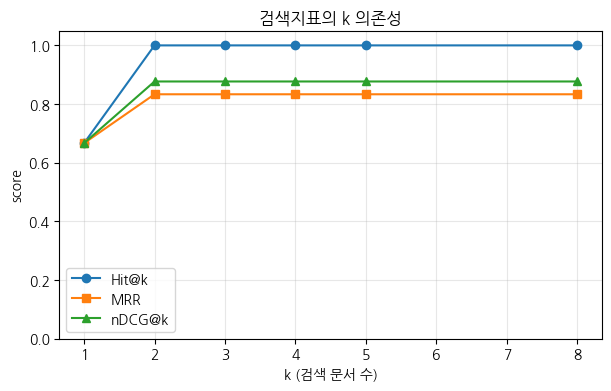

In [28]:
import matplotlib.pyplot as plt

ks = [1, 2, 3, 4, 5, 8]
hit_curve, mrr_curve, ndcg_curve = [], [], []
for k in ks:
    m = eval_retrieval(GOLD, k=k)
    hit_curve.append(m["Hit@k"]); mrr_curve.append(m["MRR"]); ndcg_curve.append(m["nDCG"])

plt.figure(figsize=(7, 4))
plt.plot(ks, hit_curve, "o-", label="Hit@k")
plt.plot(ks, mrr_curve, "s-", label="MRR")
plt.plot(ks, ndcg_curve, "^-", label="nDCG@k")
plt.xlabel("k (검색 문서 수)"); plt.ylabel("score"); plt.ylim(0, 1.05)
plt.title("검색지표의 k 의존성"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

> 관찰: k가 커지면 Hit@k는 단조 증가(또는 유지)하지만, MRR은 상위 순위 품질이라 k에 둔감

## judge 점수 시각화 (faithfulness / answer_relevancy)
- 모은 `gen_rows`를 질문별 막대그래프로 시각화해 **어느 질문이 약한지** 눈으로 보기

### 질문별 답변 품질 막대그래프
- 어떤 질문에서 답이 약한지 **한눈에** 보기
- 막대가 낮은 질문(Q번호)이 개선 대상


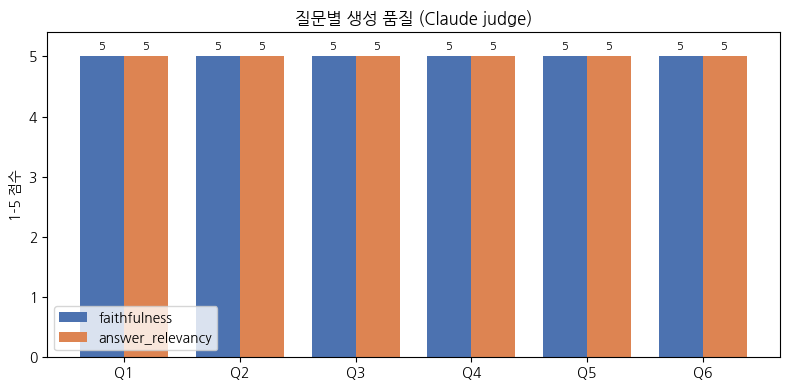

Q1: 노바테크의 CEO는 누구인가?
Q2: 그린모빌리티의 주력 제품은?
Q3: 노바테크의 경쟁사는?
Q4: 노바테크의 자회사는?
Q5: 그린모빌리티의 CFO는?
Q6: 노바테크의 2023년 배당은 주당 얼마인가?


In [29]:
import numpy as np

labels = [f"Q{i+1}" for i in range(len(gen_rows))]
faith_v = [r["faithfulness"] for r in gen_rows]
rel_v   = [r["answer_relevancy"] for r in gen_rows]
x = np.arange(len(labels)); w = 0.38

plt.figure(figsize=(8, 4))
plt.bar(x - w/2, faith_v, w, label="faithfulness", color="#4C72B0")
plt.bar(x + w/2, rel_v,   w, label="answer_relevancy", color="#DD8452")
plt.xticks(x, labels); plt.ylim(0, 5.4); plt.ylabel("1-5 점수")
plt.title("질문별 생성 품질 (Claude judge)"); plt.legend()
for i, (f, r) in enumerate(zip(faith_v, rel_v)):
    plt.text(i - w/2, f + 0.1, str(f), ha="center", fontsize=8)
    plt.text(i + w/2, r + 0.1, str(r), ha="center", fontsize=8)
plt.tight_layout(); plt.show()
for lab, g in zip(labels, gen_rows):
    print(lab + ": " + g["q"])

## rubric 민감도 실험
- 같은 답변을 **느슨한 rubric**과 **엄격한 rubric**으로 각각 채점해, judge가 rubric에 얼마나 민감한지 측정
- 이는 LLM-as-a-judge의 핵심 신뢰성 이슈: **rubric을 바꾸면 점수가 달라짐**

### 채점 기준(rubric)을 바꿔보는 실험
- **같은 답변**을 느슨한 기준과 엄격한 기준으로 각각 채점함
- LLM 채점관은 기준 문장에 민감해서, **기준이 바뀌면 점수가 달라짐**
- 이걸 직접 확인해 "왜 팀에서 채점 기준을 하나로 고정해야 하는지" 체감
- **출력 읽는 법**: 느슨/엄격 평균 차이가 클수록 채점관이 기준에 예민하다는 뜻


In [30]:
# 정확도가 더 필요하면 이 judge/추출 셀의 모델을 MODEL_JUDGE = "claude-opus-4-8" 로 한 줄 상향 가능(기본은 비용 위해 sonnet 4.6).
def judge_with_rubric(question, answer, contexts, rubric_text):
    """rubric 문구를 주입해 동일 답변을 다른 기준으로 채점."""
    ctx = "\n".join(contexts)
    tool = [{
      "name": "report_judgment",
      "description": "RAG 답변 평가 결과 보고",
      "input_schema": {"type": "object", "properties": {
          "reasoning": {"type": "string"},
          "faithfulness": {"type": "integer", "description": "1-5"},
          "answer_relevancy": {"type": "integer", "description": "1-5"},
      }, "required": ["reasoning", "faithfulness", "answer_relevancy"]}
    }]
    msg = client.messages.create(model=MODEL, max_tokens=700, tools=tool,
        tool_choice={"type": "tool", "name": "report_judgment"},
        messages=[{"role": "user", "content":
            f"채점 기준: {rubric_text}\n질문:{question}\n근거:{ctx}\n답변:{answer}\n"
            "reasoning을 먼저 쓰고 1-5로 채점하라."}])
    for b in msg.content:
        if b.type == "tool_use": return b.input

LENIENT = "대체로 맞으면 후하게 4~5점을 줘라. 사소한 누락은 감점하지 마라."
STRICT  = "근거에 명시되지 않은 단어가 하나라도 있으면 faithfulness를 2점 이하로 크게 깎아라. 매우 엄격히."

# 예상 호출: 골든 QA 6건 × 2 rubric = 12 judge 호출 (소규모)
lenient_f, strict_f = [], []
for g in GOLD:
    ctxs = search(g["q"], k=4)
    ans = rag_answer(g["q"], ctxs)
    lenient_f.append(judge_with_rubric(g["q"], ans, ctxs, LENIENT)["faithfulness"])
    strict_f.append(judge_with_rubric(g["q"], ans, ctxs, STRICT)["faithfulness"])

import statistics as st2
print(f"느슨한 rubric 평균 faithfulness: {st2.mean(lenient_f):.2f}")
print(f"엄격한 rubric 평균 faithfulness: {st2.mean(strict_f):.2f}")
print(f"평균 차이(민감도): {st2.mean(lenient_f) - st2.mean(strict_f):.2f}")

느슨한 rubric 평균 faithfulness: 5.00
엄격한 rubric 평균 faithfulness: 5.00
평균 차이(민감도): 0.00


### 기준 민감도 막대그래프
- 질문별로 느슨/엄격 두 점수를 나란히 그림
- **두 막대 차이가 클수록** 그 질문에서 채점이 기준에 휘둘린다는 뜻


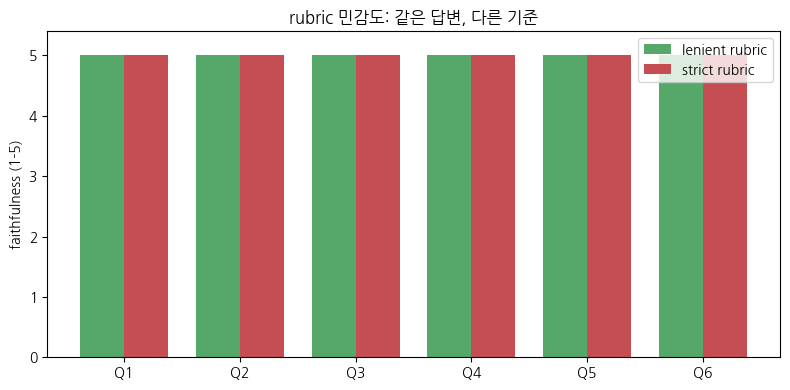

In [31]:
# rubric 민감도 시각화
x = np.arange(len(GOLD)); w = 0.38
plt.figure(figsize=(8, 4))
plt.bar(x - w/2, lenient_f, w, label="lenient rubric", color="#55A868")
plt.bar(x + w/2, strict_f,  w, label="strict rubric",  color="#C44E52")
plt.xticks(x, [f"Q{i+1}" for i in range(len(GOLD))]); plt.ylim(0, 5.4)
plt.ylabel("faithfulness (1-5)"); plt.title("rubric 민감도: 같은 답변, 다른 기준")
plt.legend(); plt.tight_layout(); plt.show()

> 해석: 두 막대 차이가 클수록 judge가 rubric 문구에 민감 → rubric을 고정/공유해야 평가가 재현

## 직접 해보기: 나만의 rubric 설계
- answer_relevancy에 대해 느슨/엄격 rubric을 직접 써서 점수 차이를 측정해 보기

In [32]:
# 직접 해보기: '적합도(answer_relevancy)'용 채점 기준을 직접 써보세요.
# 힌트: 아래 따옴표 안에 한국어 문장으로 기준을 적으면 됩니다. 예시를 참고해 바꿔보세요.
MY_LENIENT = "질문과 대충 관련만 있으면 4~5점을 줘라."          # <- 느슨한 기준 예시
MY_STRICT  = "질문이 물은 핵심을 정확히 답하지 않으면 2점 이하로 깎아라."  # <- 엄격한 기준 예시

g = GOLD[0]; ctxs = search(g['q'], 4); ans = rag_answer(g['q'], ctxs)
lenient = judge_with_rubric(g['q'], ans, ctxs, MY_LENIENT)['answer_relevancy']
strict  = judge_with_rubric(g['q'], ans, ctxs, MY_STRICT)['answer_relevancy']
print(f'느슨 기준 적합도={lenient}  엄격 기준 적합도={strict}  (차이가 크면 기준에 민감)')


느슨 기준 적합도=5  엄격 기준 적합도=5  (차이가 크면 기준에 민감)


## 검증: rubric 민감도

### 실험이 말이 되는지 검증
- 엄격한 기준 평균이 느슨한 기준 평균보다 높지 않은지, 점수가 1~5 범위인지 확인
- `통과`면 실험 설계가 정상


In [33]:
# 엄격 rubric의 평균이 느슨 rubric 평균을 초과하지 않아야 한다(엄격할수록 같거나 낮음)
assert st2.mean(strict_f) <= st2.mean(lenient_f) + 1e-6, "엄격 rubric이 더 후하면 실험 설계 점검"
# 모든 점수가 1~5 범위
assert all(1 <= v <= 5 for v in lenient_f + strict_f), "점수 범위 오류"
print("rubric 민감도 실험 검증 통과")

rubric 민감도 실험 검증 통과


## 평가 비용 줄이기 ① — prompt caching judge
- 골든셋이 커지면 judge를 수백·수천 번 부름
- judge 프롬프트에는 **매번 똑같은 부분**(채점 rubric/지침)과 **반복되는 부분**(같은 근거 컨텍스트)이 있음
- 안 바뀌는 앞부분을 **캐시**하면 두 번째 호출부터 거의 공짜로 처리됨 (캐시 읽기 ~0.1x, 최대 90%↓)

> 쉽게 말하면 같은 자료를 계속 다시 읽히면 돈이 든다 → 안 바뀌는 앞부분(rubric·context)을 '캐시'해 두면 두 번째부터 거의 공짜

**용어**: *prompt caching* = 프롬프트의 고정된 앞부분을 서버가 기억해 재사용(prefix-match). *ephemeral* = 짧게 유지되는 캐시


In [34]:
# prompt caching을 적용한 judge — 런타임 비의존 '코드 패턴'(그대로 돌려도 동작)
# 핵심: '안 바뀌는 앞부분'(SYSTEM_RUBRIC, 같은 context)을 system 블록 앞쪽에 두고 cache_control을 건다.
SYSTEM_RUBRIC = ("당신은 RAG 답변 채점관입니다. 근거 충실도(faithfulness)와 질문 적합도(answer_relevancy)를 "
                 "각각 1-5로 채점하고, 길이가 길다는 이유로 가점하지 마세요. reasoning을 먼저 작성하세요.")

def judge_cached(question, answer, contexts):
    """rubric(고정) + context(반복)를 캐시해 반복 채점 비용을 줄인 judge."""
    ctx = "\n".join(contexts)
    msg = client.messages.create(
        model=MODEL, max_tokens=700,
        system=[
            {"type": "text", "text": SYSTEM_RUBRIC,
             "cache_control": {"type": "ephemeral"}},   # 고정 rubric을 캐시
            {"type": "text", "text": f"근거:\n{ctx}",
             "cache_control": {"type": "ephemeral"}},    # 같은 context 반복 채점 시 prefix 캐시 적중
        ],
        tools=JUDGE_TOOL, tool_choice={"type": "tool", "name": "report_judgment"},
        messages=[{"role": "user", "content": f"질문:{question}\n답변:{answer}\n1-5로 채점."}],
    )
    for b in msg.content:
        if b.type == "tool_use":
            return b.input

# 데모: 같은 context로 두 번 채점하면 두 번째 호출은 캐시를 읽어 입력 토큰 비용이 급감.
# (정확도가 더 필요하면 judge 모델을 MODEL_JUDGE="claude-opus-4-8"로 상향 가능)
_demo = GOLD[0]
_ctxs = search(_demo["q"], k=4)
_ans = rag_answer(_demo["q"], _ctxs)
print("캐싱 judge 판정:", judge_cached(_demo["q"], _ans, _ctxs))
print("→ 같은 rubric/context를 반복 채점할수록 캐시 적중으로 비용이 크게 준다(최대 90%↓).")


캐싱 judge 판정: {'reasoning': '\n근거 충실도(faithfulness): 답변에서 "노바테크의 CEO는 김하늘이며, 2021년에 취임했습니다"라고 했는데, 이는 근거 "노바테크의 CEO는 김하늘이며 2021년 취임했다"와 정확히 일치한다. 근거에 없는 내용을 추가하거나 왜곡한 부분이 없으므로 충실도는 최고점인 5점.\n\n질문 적합도(answer_relevancy): 질문은 "노바테크의 CEO는 누구인가?"이며, 답변은 CEO가 김하늘임을 명확히 밝히고 취임 연도까지 부가 정보로 제공했다. 질문에 완벽히 답하고 있으며 불필요하거나 무관한 내용이 없으므로 5점.\n', 'faithfulness': 5, 'answer_relevancy': 5}
→ 같은 rubric/context를 반복 채점할수록 캐시 적중으로 비용이 크게 준다(최대 90%↓).


## 평가 비용 줄이기 ② — Batches API로 골든셋 대량 채점
- 실시간 응답이 필요 없는 **회귀 평가/야간 배치**라면, judge 호출을 한 번에 묶어 보내는 **Batches API**가 이상적
- **모든 토큰 50% 할인**, 비동기(최대 24시간 내 완료). 골든셋 수백~수천 건을 한 번에 채점할 때 적합

> 쉽게 말하면 급하지 않은 채점은 '한꺼번에 모아 밤에 돌리기' → 반값. 단 결과는 **즉시가 아니라** 나중에 받음

아래는 **런타임 비의존 패턴 셀**(`RUN_BATCH=False`라 실제 제출은 하지 않음)  
실제로 돌리려면 `RUN_BATCH=True`로 바꾸고
완료될 때까지 `batch.id`로 폴링하기(즉시 결과가 아님)


In [35]:
# Batches API로 골든셋 전체를 한 번에 judge 채점하는 패턴
# 동기 호출은 느리고 비싸다 → Batches로 50% 절감(단 결과는 비동기, 즉시 아님)
RUN_BATCH = False  # 실제 제출은 비용/시간이 들고 비동기라 기본 False. 패턴 이해용

def judge_prompt(item):
    """골든셋 1건 → judge 사용자 메시지 텍스트."""
    ctxs = search(item["q"], k=4)
    ans = rag_answer(item["q"], ctxs)
    ctx = "\n".join(ctxs)
    return f"질문:{item['q']}\n근거:{ctx}\n답변:{ans}\n1-5로 faithfulness/answer_relevancy 채점."

if RUN_BATCH:
    # 골든셋 전체를 하나의 배치 요청으로 묶는다(모든 토큰 50% 할인).
    batch = client.messages.batches.create(
        requests=[
            {"custom_id": f"q{i}",
             "params": {"model": MODEL, "max_tokens": 512,
                        "tools": JUDGE_TOOL,
                        "tool_choice": {"type": "tool", "name": "report_judgment"},
                        "messages": [{"role": "user", "content": judge_prompt(item)}]}}
            for i, item in enumerate(GOLD)
        ]
    )
    print("배치 제출됨. batch.id =", batch.id)
    # 완료까지 폴링 → 완료 후 결과 취합:
    #   while client.messages.batches.retrieve(batch.id).processing_status != "ended": time.sleep(30)
    #   for r in client.messages.batches.results(batch.id): ...
    print("→ 실시간이 불필요한 회귀평가/야간 배치에 적합. (결과는 비동기로 도착)")
else:
    print("RUN_BATCH=False — Batches API 패턴만 확인(실제 제출 안 함)")
    print("핵심: 대량 judge 채점은 Batches로 50% 절감, 단 비동기(즉시 결과 아님)")
    print("→ 실시간 단건 채점은 동기 호출, 골든셋 대량 회귀평가는 Batches가 정석")


RUN_BATCH=False — Batches API 패턴만 확인(실제 제출 안 함)
핵심: 대량 judge 채점은 Batches로 50% 절감, 단 비동기(즉시 결과 아님)
→ 실시간 단건 채점은 동기 호출, 골든셋 대량 회귀평가는 Batches가 정석


## 확장과제
- **RAGAS 연동(선택)**: `!pip install ragas` 후 동일 골든셋으로 faithfulness를 RAGAS 점수와 교차검증
- **Position bias 완화**: 쌍대비교(A/B)에서 순서를 뒤집어 두 번 채점하고 평균 → 자세한 실험은 (평가 심화)에서
- **rubric 고정 정책**: 위 민감도 결과를 근거로 팀 표준 rubric을 1개로 고정하라
- 검색 약점이 보였다면 → lab3(Hybrid), lab4(Rerank)로 개선 후 같은 골든셋 재평가

> 평가 심화(쌍대비교·position/length bias 실험)는 다음 파트에서 이어짐

---
# RAG 평가 심화 (쌍대비교 · position/length bias 실험)

## 학습목표
- LLM-as-a-judge의 **쌍대비교(pairwise)** 모드를 구현
- judge의 두 가지 대표 편향을 **실험으로 측정**: **position bias**(순서 편향), **length bias**(길이 편향)
- 편향을 **완화**하는 기법(순서 스왑 평균)을 적용하고 효과를 확인

## 사전개념
- 이전까지 **점수형(pointwise) judge**를 수행함
- 여기서는 **쌍대비교**(A vs B 어느 답이 더 나은가)를 다룸
- **Position bias**: 같은 두 답을 순서만 바꿔 물으면 판정이 달라지는 현상(앞/뒤 선호)
- **Length bias**: 더 길고 장황한 답을 (내용과 무관하게) 더 좋게 보는 경향

> "judge도 모델이다: judge를 평가(meta-evaluation)해야 함"  
비-Claude 라이브러리 없음(평가는 전부 Claude)

## 용어 미니 사전 (평가 심화 편)
- 이전에는 답 하나에 점수를 매김
- 여기선 **두 답 중 누가 나은지** 고르게 하고, 그 판정이 공정한지 따짐

| 용어 | 한 줄 뜻 |
|---|---|
| **점수형(pointwise)** | 답 1개를 1~5점으로 채점 |
| **쌍대비교(pairwise)** | 답 A vs B 중 더 나은 쪽을 고름 (상대 평가라 더 안정적) |
| **position bias(순서 편향)** | 두 답의 *제시 순서*만 바꿨는데 판정이 달라지는 현상 |
| **length bias(길이 편향)** | 내용이 같아도 *더 긴 답*을 괜히 좋게 보는 경향 |
| **순서 스왑 평균** | A→B 순서, B→A 순서로 둘 다 물어 평균 내 순서 편향을 줄이는 기법 |

> 핵심 메시지: **채점관(judge)도 결국 모델이라 편향이 있음**  
그래서 채점관 자체를 검증(meta-evaluation)해야 함


## 개념 복습: judge 3모드와 편향

| 모드 | 출력 | 특징 |
|---|---|---|
| 점수형(pointwise) | 답 1개에 1-5 | 절대 기준 필요(rubric 민감) |
| **쌍대비교(pairwise)** | A/B 중 승자 | 상대 비교라 안정적, 단 **순서 편향** 존재 |
| 이진(binary) | 통과/실패 | 게이트용 |

쌍대비교는 점수형보다 일관되지만, **어느 답을 먼저 보여주냐**(position)와 **답 길이**(length)에 흔들림

## 평가 대상 답변 쌍 준비
- 같은 질문에 대해 **간결·정확한 A**와 **장황하지만 군더더기 있는 B**를 준비(합성)

### 비교할 답변 두 개 준비
- 같은 질문에 대해 **A=간결·정확한 답**과 **B=장황하지만 군더더기 있는 답**을 만들기 (둘 다 사실은 맞음)
- 뒤에서 채점관이 어느 쪽을 고르는지, 길이에 휘둘리는지 볼 재료
- 출력은 두 답의 글자 수


In [36]:
QUESTION = "노바테크의 CEO는 누구이며 언제 취임했는가?"
CONTEXT = "노바테크의 CEO는 김하늘이며 2021년 취임 후 AI 가속기 사업을 확장했다."

# A: 간결·정확  B: 장황(같은 사실 + 군더더기)
ANS_A = "노바테크의 CEO는 김하늘이며 2021년에 취임했다. [1]"
ANS_B = ("노바테크라는 가상의 반도체 설계 기업에 대해 말씀드리자면, 이 회사의 최고경영자 즉 CEO는 "
         "김하늘이라는 분이고, 그분께서 자리에 오르신 시점은 2021년으로 알려져 있으며, 이후 다양한 "
         "사업 확장을 추진해 왔다고 합니다. [1]")
print("A 길이:", len(ANS_A), "| B 길이:", len(ANS_B))

A 길이: 33 | B 길이: 128


## 쌍대비교 judge 구현
- tool use로 승자(A/B/tie)를 강제 출력
- reasoning을 먼저 받아 CoT를 유도

### '둘 중 승자 고르기' 채점관 만들기
- Claude에게 답 A/B 중 더 나은 쪽(또는 무승부 tie)을 고르게 함
- 도구(tool) 형식으로 **반드시 A/B/tie 중 하나**만 답하게 강제함
- **출력 읽는 법**: `→ A` 또는 `→ B`가 승자. 이유(reasoning)도 함께 출력


In [37]:
# 정확도가 더 필요하면 이 judge/추출 셀의 모델을 MODEL_JUDGE = "claude-opus-4-8" 로 한 줄 상향 가능(기본은 비용 위해 sonnet 4.6).
PAIRWISE_TOOL = [{
  "name": "pick_winner",
  "description": "두 답변 중 근거 충실성과 질문 적합성이 더 나은 쪽을 고른다",
  "input_schema": {"type": "object", "properties": {
      "reasoning": {"type": "string", "description": "비교 근거(먼저 작성)"},
      "winner": {"type": "string", "enum": ["A", "B", "tie"]},
  }, "required": ["reasoning", "winner"]}
}]

def pairwise(question, context, first, second):
    """first/second 순서로 제시. 반환 winner는 제시 순서 기준 A/B."""
    msg = client.messages.create(
        model=MODEL,
        max_tokens=500,
        tools=PAIRWISE_TOOL,
        tool_choice={"type": "tool", "name": "pick_winner"},
        messages=[{
            "role": "user",
            "content": f"질문:{question}\n근거:{context}\n\n답변 A:\n{first}\n\n답변 B:\n{second}\n\n" \
                       "근거 충실성과 질문 적합성 기준으로 A/B/tie를 고르라. reasoning 먼저."
        }]
    )
    for b in msg.content:
        if b.type == "tool_use":
            tool_output = b.input
            # Ensure 'winner' is present, defaulting to 'tie' if missing from model's tool output
            if "winner" not in tool_output:
                tool_output["winner"] = "tie"
            # Ensure 'reasoning' is present, defaulting if missing
            if "reasoning" not in tool_output:
                tool_output["reasoning"] = "No reasoning provided."
            return tool_output
    # Fallback if no tool_use block is found at all (should not happen with tool_choice forced)
    return {"reasoning": "Model failed to use tool.", "winner": "tie"}

res = pairwise(QUESTION, CONTEXT, ANS_A, ANS_B)
print("A=간결, B=장황 제시 →", res["winner"])
print("이유:", res["reasoning"][:120], "...")

A=간결, B=장황 제시 → A
이유: 
**근거 충실성:**
- 답변 A: 근거에 있는 핵심 정보(CEO = 김하늘, 취임 연도 = 2021년)를 정확하게 반영했다. 근거에 없는 내용을 추가하지 않았다.
- 답변 B: 근거에 없는 "가상의 반도체 설계  ...


## Position bias 실험
- **같은 두 답을 순서만 바꿔** 여러 번 물어, 제시 위치에 따라 판정이 흔들리는지 측정
- 진짜 품질 차이라면 순서를 바꿔도 **같은 실제 답**이 이겨야 함

### 순서 편향 측정 실험
- **같은 두 답을 순서만 바꿔** 여러 번 물어봄
- 진짜 품질 차이라면 순서를 바꿔도 같은 답이 이겨야 함
- 만약 순서 따라 승자가 바뀌면 → 순서 편향이 있는 것
- **출력 읽는 법**: 마지막 `position bias 지표`가 **0이면 편향 없음**, 1에 가까울수록 순서에 휘둘린다는 뜻 (Claude를 여러 번 부르므로 30초~1분 걸릴 수 있음)


In [38]:
# 실제 우수안 = 간결·정확한 쪽(여기선 ANS_A로 간주)
# 주의: 이 셀을 실행하기 전에 'pairwise' 함수가 정의된 이전 셀을 먼저 실행해주세요.
# 순서1: (A=간결, B=장황) → 간결이 이기면 winner == "A"
# 순서2: (A=장황, B=간결) → 간결이 이기면 winner == "B"
N = 5  # 반복(노이즈 평균). 예상 호출: 2*N judge
order1_concise_win = 0  # 간결이 이긴 횟수 (순서1)
order2_concise_win = 0  # 간결이 이긴 횟수 (순서2)
for _ in range(N):
    r1 = pairwise(QUESTION, CONTEXT, ANS_A, ANS_B)  # 간결 먼저
    if r1.get("winner") == "A": order1_concise_win += 1
    r2 = pairwise(QUESTION, CONTEXT, ANS_B, ANS_A)  # 장황 먼저
    if r2.get("winner") == "B": order2_concise_win += 1

print(f"순서1(간결 먼저) 간결 승: {order1_concise_win}/{N}")
print(f"순서2(장황 먼저) 간결 승: {order2_concise_win}/{N}")
flip = abs(order1_concise_win - order2_concise_win) / N
print(f"position bias 지표(순서에 따른 판정 변동률): {flip:.2f}  (0=편향없음)")

순서1(간결 먼저) 간결 승: 0/5
순서2(장황 먼저) 간결 승: 0/5
position bias 지표(순서에 따른 판정 변동률): 0.00  (0=편향없음)


## Position bias 완화 — 순서 스왑 평균
- 두 순서로 각각 묻고 **둘 다 같은 실제 답을 이겼을 때만** 승리로 인정하는 **양방향 합의** 판정을 만들기

### 순서 편향 줄이기(양방향 합의)
- A→B 순서와 B→A 순서로 **둘 다 물어보고**, 두 번 다 이긴 쪽만 승자로 인정
- 이렇게 하면 순서 편향에 강해짐


In [39]:
def pairwise_debiased(question, context, real_a, real_b):
    """real_a, real_b를 두 순서로 모두 물어 합의로 판정. 반환: \"A\"/\"B\"/\"tie\"."""
    r1 = pairwise(question, context, real_a, real_b)  # real_a가 A위치
    r2 = pairwise(question, context, real_b, real_a)  # real_a가 B위치
    # r1에서 real_a 승 = "A", r2에서 real_a 승 = "B"
    a_wins = (r1["winner"] == "A") + (r2["winner"] == "B")
    b_wins = (r1["winner"] == "B") + (r2["winner"] == "A")
    if a_wins > b_wins: return "A"
    if b_wins > a_wins: return "B"
    return "tie"

verdict = pairwise_debiased(QUESTION, CONTEXT, ANS_A, ANS_B)
print("양방향 합의 판정 (A=간결):", verdict)

양방향 합의 판정 (A=간결): A


> 순서를 모두 고려하므로 단일 순서 판정보다 position bias에 강건

## Length bias 실험
- **내용은 동일**한데 길이만 다른 두 답(짧음 vs 늘려쓴 것)을 비교해, judge가 긴 답을 선호하는지 보기
- 내용이 같으므로 이상적 판정은 **tie**여야 함

### 길이 편향 측정 실험
- **내용은 똑같고 길이만 다른** 두 답(짧음 vs 늘려쓴 것)을 비교함
- 내용이 같으니 이상적 판정은 무승부(tie)여야 함
- **출력 읽는 법**: `length bias 지표`는 긴 답이 이긴 비율
- **0이면 길이 편향 없음**(긴 답을 더 선호하지 않음), **0.5 이상이면 긴 답을 절반 넘게 선호 → 길이 편향 의심** (앞의 position bias 지표와 똑같이 **0 = 편향 없음** 기준으로 읽으면 됨)


In [40]:
SHORT = "노바테크의 CEO는 김하늘이고 2021년 취임했다. [1]"
# 동일 사실을 단순 반복/수식어로 늘린 버전(추가 정보 없음)
PADDED = ("노바테크의 CEO는 김하늘입니다. 다시 말해 노바테크의 최고경영자는 김하늘이라는 인물이며, "
          "그가 취임한 해는 2021년입니다. 즉 2021년에 김하늘이 노바테크의 CEO가 되었다는 의미입니다. [1]")

N = 6  # 예상 호출: 2*N (양 순서)
padded_win = tie = short_win = 0
for _ in range(N):
    v = pairwise_debiased(QUESTION, CONTEXT, SHORT, PADDED)  # A=SHORT, B=PADDED
    if v == "B": padded_win += 1
    elif v == "A": short_win += 1
    else: tie += 1
print(f"내용 동일, 길이만 다름 → 긴답 승:{padded_win}  짧은답 승:{short_win}  tie:{tie}  (이상적=tie 다수)")
# length bias = '긴 답이 이긴 비율'. 내용이 같으니 이상적으로는 긴 답이 이길 이유가 없다.
#   0   = 긴 답을 전혀 더 선호하지 않음(= 길이 편향 없음)  ← position bias와 동일하게 '0=편향없음' 기준
#   0.5 이상 = 긴 답을 절반 넘게 선호 → 길이 편향 의심(주의선)
#   1   = 항상 긴 답을 선택(강한 길이 편향)
length_bias = padded_win / N   # 긴 답이 이긴 비율(tie/짧은답 승은 분자에 넣지 않음 → 0=편향없음)
print(f"length bias 지표(긴답 승률): {length_bias:.2f}  (0=편향없음, 0.5↑=긴답 절반초과 선호→편향 의심)")

내용 동일, 길이만 다름 → 긴답 승:0  짧은답 승:3  tie:3  (이상적=tie 다수)
length bias 지표(긴답 승률): 0.00  (0=편향없음, 0.5↑=긴답 절반초과 선호→편향 의심)


## 편향 종합 시각화
- position bias와 length bias 지표를 막대그래프로 요약함

### 두 편향을 막대그래프로 요약
- 순서 편향과 길이 편향을 한 그래프로 봄
- **그래프 읽는 법**: 두 막대 모두 **낮을수록(0에 가까울수록) 좋음**
- 초록 점선(0)이 "편향 없음" 기준, 회색 점선(0.5)은 "긴 답을 절반 넘게 선호"하는 주의선
- 길이 편향 막대가 0.5 주의선을 넘으면 길이 편향이 의심됨


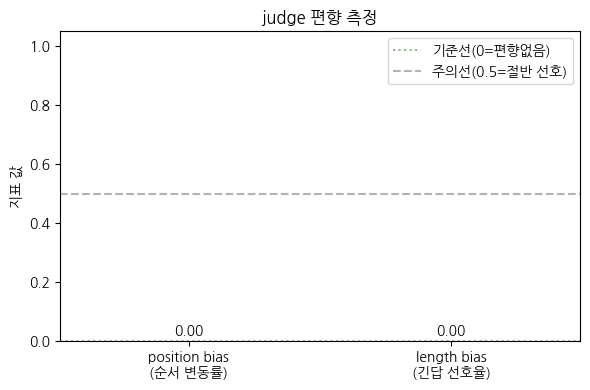

In [41]:
import matplotlib.pyplot as plt

metrics = {"position bias\n(순서 변동률)": flip, "length bias\n(긴답 선호율)": length_bias}
plt.figure(figsize=(6, 4))
bars = plt.bar(list(metrics.keys()), list(metrics.values()),
               color=["#4C72B0", "#C44E52"])
plt.axhline(0.0, ls=":", c="green", alpha=0.5, label="기준선(0=편향없음)")
plt.axhline(0.5, ls="--", c="gray", alpha=0.6, label="주의선(0.5=절반 선호)")
plt.ylim(0, 1.05); plt.ylabel("지표 값"); plt.title("judge 편향 측정")
for b, v in zip(bars, metrics.values()):
    plt.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center")
plt.legend(); plt.tight_layout(); plt.show()

> 해석: 두 지표 모두 "0=편향없음" 기준  
position 변동률이 0보다 크면 순서 편향 존재 → 양방향 스왑으로 완화  
length 승률이 0이면 길이 편향 없음, 0.5(주의선) 이상이면 긴 답 편애 → rubric에 "길이로 보상하지 말라" 명시

## 직접 해보기: length bias 완화 rubric
- 쌍대비교 프롬프트에 "길이가 길다는 이유로 더 높게 평가하지 말기
- 추가 정보가 없으면 tie"를 넣고 length bias가 줄어드는지 측정

In [42]:
# 직접 해보기: '길이로 점수 주지 말라'는 지침을 넣으면 길이 편향이 줄까요?
# 힌트: 채점 지침 한 줄을 프롬프트 앞에 붙인 새 함수를 만들어 SHORT vs PADDED를 다시 비교합니다.
def pairwise_guided(question, context, first, second,
                    guide="채점 지침: 길이가 길다는 이유로 더 높게 평가하지 말 것. 추가 정보가 없으면 tie."):
    msg = client.messages.create(model=MODEL, max_tokens=500, tools=PAIRWISE_TOOL,
        tool_choice={"type": "tool", "name": "pick_winner"},
        messages=[{"role": "user", "content":
            f"{guide}\n질문:{question}\n근거:{context}\n\n답변 A:\n{first}\n\n답변 B:\n{second}\n\n"
            "A/B/tie를 고르라. reasoning 먼저."}])
    for b in msg.content:
        if b.type == "tool_use": return b.input

guided_padded_win = 0
for _ in range(4):
    r = pairwise_guided(QUESTION, CONTEXT, SHORT, PADDED)
    if r["winner"] == "B": guided_padded_win += 1   # B=긴 답
print(f"지침 추가 후 긴답 승: {guided_padded_win}/4  (앞 실험보다 줄면 길이 편향 완화 성공)")


지침 추가 후 긴답 승: 0/4  (앞 실험보다 줄면 길이 편향 완화 성공)


## 직접 해보기: 진짜 품질 차이 검출
- 근거에 **없는 사실을 넣은 환각 답**(C)과 정확한 답(A)을 쌍대비교해, debiased judge가 A를 일관되게 고르는지 확인

In [43]:
# 직접 해보기: 근거에 없는 '환각 답'을 넣어도 채점관이 정답을 가려낼까요?
# 힌트: 근거에 없는 수치를 넣은 틀린 답(HALLUC)과 정답(ANS_A)을 양방향 비교합니다.
HALLUC = "노바테크의 CEO는 김하늘이며 2019년 취임했고 매출은 5조원이다. [1]"  # 2019, 5조원은 근거에 없음(환각)
wins_A = 0
for _ in range(4):
    if pairwise_debiased(QUESTION, CONTEXT, ANS_A, HALLUC) == 'A':
        wins_A += 1
print(f'정답(A)이 환각답을 이긴 횟수: {wins_A}/4  (대부분 A면, 편향 완화 후에도 진짜 품질차는 잘 잡아냄)')


정답(A)이 환각답을 이긴 횟수: 4/4  (대부분 A면, 편향 완화 후에도 진짜 품질차는 잘 잡아냄)


## 검증

In [44]:
# 1) pairwise는 A/B/tie 중 하나를 반환
assert res["winner"] in ("A", "B", "tie")
# 2) debiased 판정도 A/B/tie
assert verdict in ("A", "B", "tie")
# 3) 편향 지표가 0~1 범위
assert 0.0 <= flip <= 1.0 and 0.0 <= length_bias <= 1.0
print("평가 심화 검증 통과")

평가 심화 검증 통과


## 확장과제
- **Elo/Bradley-Terry**: 여러 답변을 쌍대비교 토너먼트로 돌려 랭킹을 매김
- **self-consistency**: 같은 판정을 여러 번 받아 다수결 → judge 분산 측정
- **judge meta-eval**: 사람 라벨(소량)과 judge 일치율(Cohen's kappa)을 계산해 judge 신뢰도를 보기
- **few-shot judge**: rubric에 모범 채점 예시를 넣어 편향·분산을 더 줄임

> position/length bias는 LLM-as-a-judge 운영의 핵심 리스크